Мейн-кун Марсик смотрит Гран-при с трибуны на кольцевой трассе длиной L = 5000 метров. После дождя маршалы решают, выпускать ли машину безопасности: её выпускают, если два болида — Ferrari и Red Bull — случайно оказываются в пределах d = 300 метров друг от друга по трассе (считая по кратчайшей дуге между ними, ведь трасса кольцевая — можно измерять расстояние в обе стороны).

Известно, что в момент аварии оба болида находятся в случайных, независимых друг от друга точках трассы (равномерно распределённых по всей окружности). Какова вероятность, что маршалы выпустят машину безопасности?

In [1]:
import matplotlib.pyplot as plt
import random


## Симуляция

In [2]:
N = 100000

L = 5000  # длина трассы, метры
d = 300   # порог для выпуска машины безопасности, метры

c = 0

x_true = []
y_true = []
x_false = []
y_false = []

for i in range(N):
    ferrari = random.uniform(0, L)
    redbull = random.uniform(0, L)

    diff = abs(ferrari - redbull)
    dist = min(diff, L - diff)  # расстояние по кратчайшей дуге кольца

    if dist < d:
        c += 1
        x_true.append(ferrari)
        y_true.append(redbull)
    else:
        x_false.append(ferrari)
        y_false.append(redbull)

res = c / N

res_true = 2 * d / L

print("Опыт:", res)
print("Теоретическая вероятность: ", res_true)

Опыт: 0.11959
Теоретическая вероятность:  0.12


## Визуализация

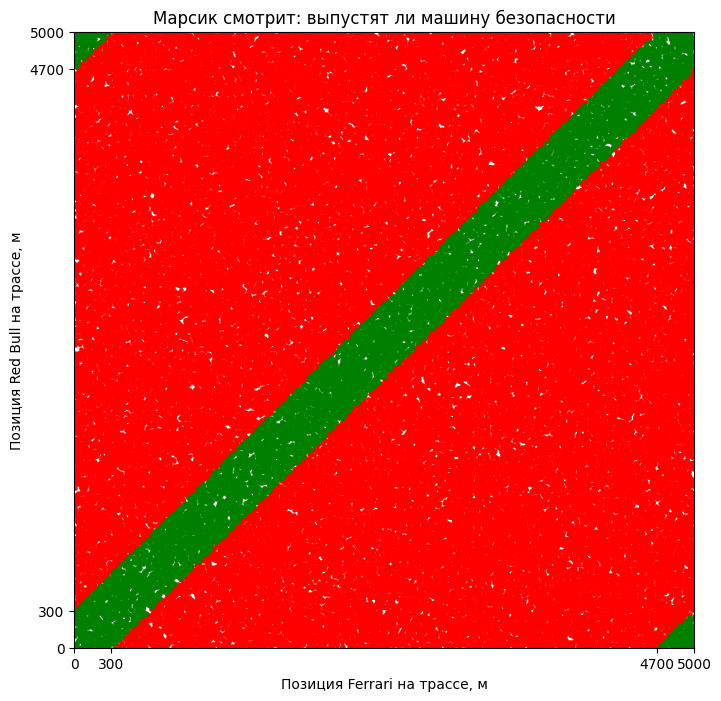

In [3]:
plt.figure(figsize=(8, 8))

plt.scatter(x_false, y_false, color='red', s=5)
plt.scatter(x_true, y_true, color='green', s=5)

plt.xlim(0, L)
plt.ylim(0, L)
plt.xticks([0, d, L - d, L])
plt.yticks([0, d, L - d, L])

plt.title("Выпустят ли машину безопасности")
plt.xlabel("Позиция Ferrari на трассе, м")
plt.ylabel("Позиция Red Bull на трассе, м")

plt.show()